# Interface Analysis — Tissue Boundary Characterization

This notebook demonstrates the unified interface analysis pipeline in spatioloji_s:

1. **Interface detection** — grid-based boundary between two tissue regions
2. **Region classification** — assign every cell to region A or B
3. **Gradient analysis** — how genes/features change across the boundary
4. **Infiltration scoring** — are immune cells penetrating into a region?

All functions work identically for point-based and polygon-based data — only cell centroid coordinates are used. No spatial graph required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spatioloji_s as sj

# Access interface functions from either module — they're the same
# sj.spatial.point.identify_interface is sj.spatial.polygon.identify_interface
import spatioloji_s.spatial.point as spoint

# Load your spatioloji object
sp = sj.data.spatioloji.from_pickle("xenium_data/morph_xenium_spatioloji.pkl")


Loading spatioloji from: xenium_data/morph_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes


In [2]:
mapping = {
    0: "Tumor",
    1: "Tumor",
    2: "Stroma",
    3: "Myeloid",
    4: "T",
    5: "Tumor",
    6: "Stroma",
    7: "Stroma",
    8: "B"
}

sp.cell_meta['cell_type'] = sp.cell_meta['leiden'].map(mapping)
# Check what cell types are available
print(sp.cell_meta["cell_type"].value_counts())

cell_type
Tumor      640372
Stroma     236143
Myeloid    133860
T           90374
B           33806
Name: count, dtype: int64


---
## 1. Interface Detection (Grid Method)

Partitions the tissue into a spatial grid, majority-votes each tile as region A or B, and extracts contour lines where A-tiles border B-tiles. Produces clean boundaries that match what you'd draw by eye.

**No spatial graph needed** — only cell coordinates and group labels.

### Key parameters

| Parameter | Effect |
|-----------|--------|
| `grid_resolution` | Tiles along the longest axis. Higher = more detail, lower = smoother. Default 50. |
| `distance_threshold` | Max distance from contour to be labeled "interface". Auto-estimated if `None`. |
| `min_interface_cells` | Drop segments with fewer than N cells on either side. |
| `close_contours` | Close loops for enclosed regions (e.g. tumor islands in stroma). |

In [3]:
# Identify interface between two regions
# Change region_a and region_b to match your cell_type labels
result = spoint.identify_interface(
    sp,
    group_col='cell_type',       # column in cell_meta with cell labels
    region_a='Tumor',            # one side of the boundary
    region_b='Stroma',           # other side
    grid_resolution=100,          # tile count along longest axis
    min_interface_cells=100,      # drop tiny segments
    coord_type='global',
    store=True,                  # saves 'interface_label' to cell_meta
)

print(f"\nSummary: {result.summary}")


[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=325.4 (1.5x tile size)
  Stored 'interface_label' in cell_meta
  422532 interface cells (251945 region_a, 170587 region_b)
  80 segment(s)

Summary: {'total_length': 189213.04871067544, 'n_segments': 80, 'mean_tortuosity': 2.571008535528065, 'n_interface_a': 251945, 'n_interface_b': 170587, 'grid_resolution': 100, 'tile_size_x': np.float64(216.90489724966196), 'tile_size_y': np.float64(214.26451036453247)}


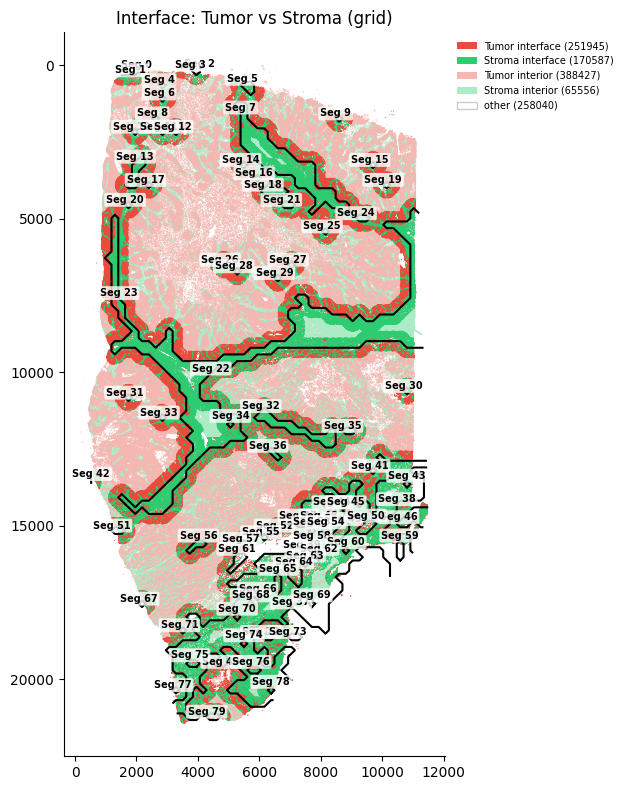

In [4]:
# Visualize — cells colored by interface role, contour lines overlay
sj.visualization.plot_interface_point_map(
    sp, result,
    color_a='#e74c3c',     # red for region A
    color_b='#2ecc71',     # green for region B
    point_size=0.5,
    contour_width=1.5,
    dpi=200,
)

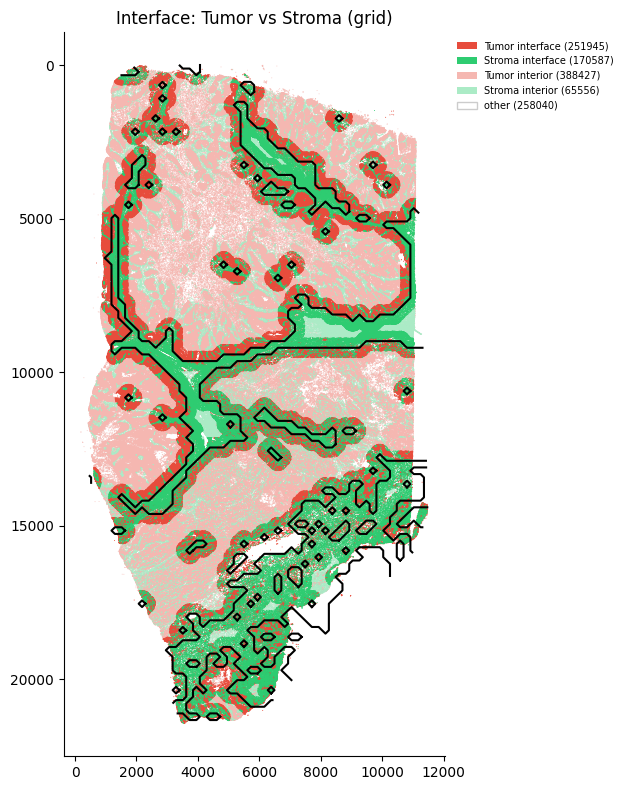

In [5]:
# Visualize — cells colored by interface role, contour lines overlay
sj.visualization.plot_interface_point_map(
    sp, result,
    color_a='#e74c3c',     # red for region A
    color_b='#2ecc71',     # green for region B
    point_size=0.5,
    contour_width=1.5,
    dpi=200, show_seg_labels=False
)

### Tuning grid_resolution

Higher resolution captures finer detail but may produce noisy boundaries. Lower resolution gives smoother, coarser boundaries.

In [12]:
resolutions = [20, 50, 100, 200]

fig, axes = plt.subplots(1, len(resolutions), figsize=(7 * len(resolutions), 8))

for ax, res in zip(axes, resolutions):
    r = spoint.identify_interface(
        sp,
        group_col='cell_type', region_a='Tumor', region_b='Stroma',
        grid_resolution=res, min_interface_cells=5,
        coord_type='global', store=False,
    )
    sj.visualization.plot_interface_point_map(
        sp, r, ax=ax, show=True, point_size=0.3,
        color_a='#e74c3c', color_b='#2ecc71',
        title=f"res={res} ({r.summary['n_segments']} segs)"
    )

plt.suptitle("Grid Resolution Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('xenium_plots/res_interface.png')


[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=1691.9 (1.5x tile size)
  575549 interface cells (389462 region_a, 186087 region_b)
  7 segment(s)

[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=650.7 (1.5x tile size)
  478819 interface cells (291467 region_a, 187352 region_b)
  22 segment(s)

[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=325.4 (1.5x tile size)
  422532 interface cells (251945 region_a, 170587 region_b)
  81 segment(s)

[Interface] Identifying interface: ['Tumor'] vs ['Stroma']
  Auto distance_threshold=161.1 (1.5x tile size)
  431880 interface cells (274627 region_a, 157253 region_b)
  330 segment(s)


<Figure size 640x480 with 0 Axes>

### Per-segment metrics

Each contour segment has metrics: `length`, `tortuosity`, `n_cells_a`, `n_cells_b`.

**Tortuosity** = actual length / straight-line distance between endpoints.
- ~1.0 = smooth pushing border (better prognosis)
- \>1.5 = irregular/invasive front (worse prognosis)

    segment_id       length  tortuosity  n_cells_a  n_cells_b
0            0   200.376582    1.000000        434        302
1            1   603.337343    1.059283       1039        526
2            2   209.486978    1.000000        254        212
3            3   826.933030    1.205157        800        303
4            4   618.877231    2.798350       2343        316
..         ...          ...         ...        ...        ...
75          75  1061.193100    2.399175        721       1467
76          76  1061.193100    2.399175       1593       2801
77          77   618.877231    2.798350        690        442
78          78   618.877231    2.798350        817       1443
79          79  1061.193100    2.399175       1505        857

[80 rows x 5 columns]


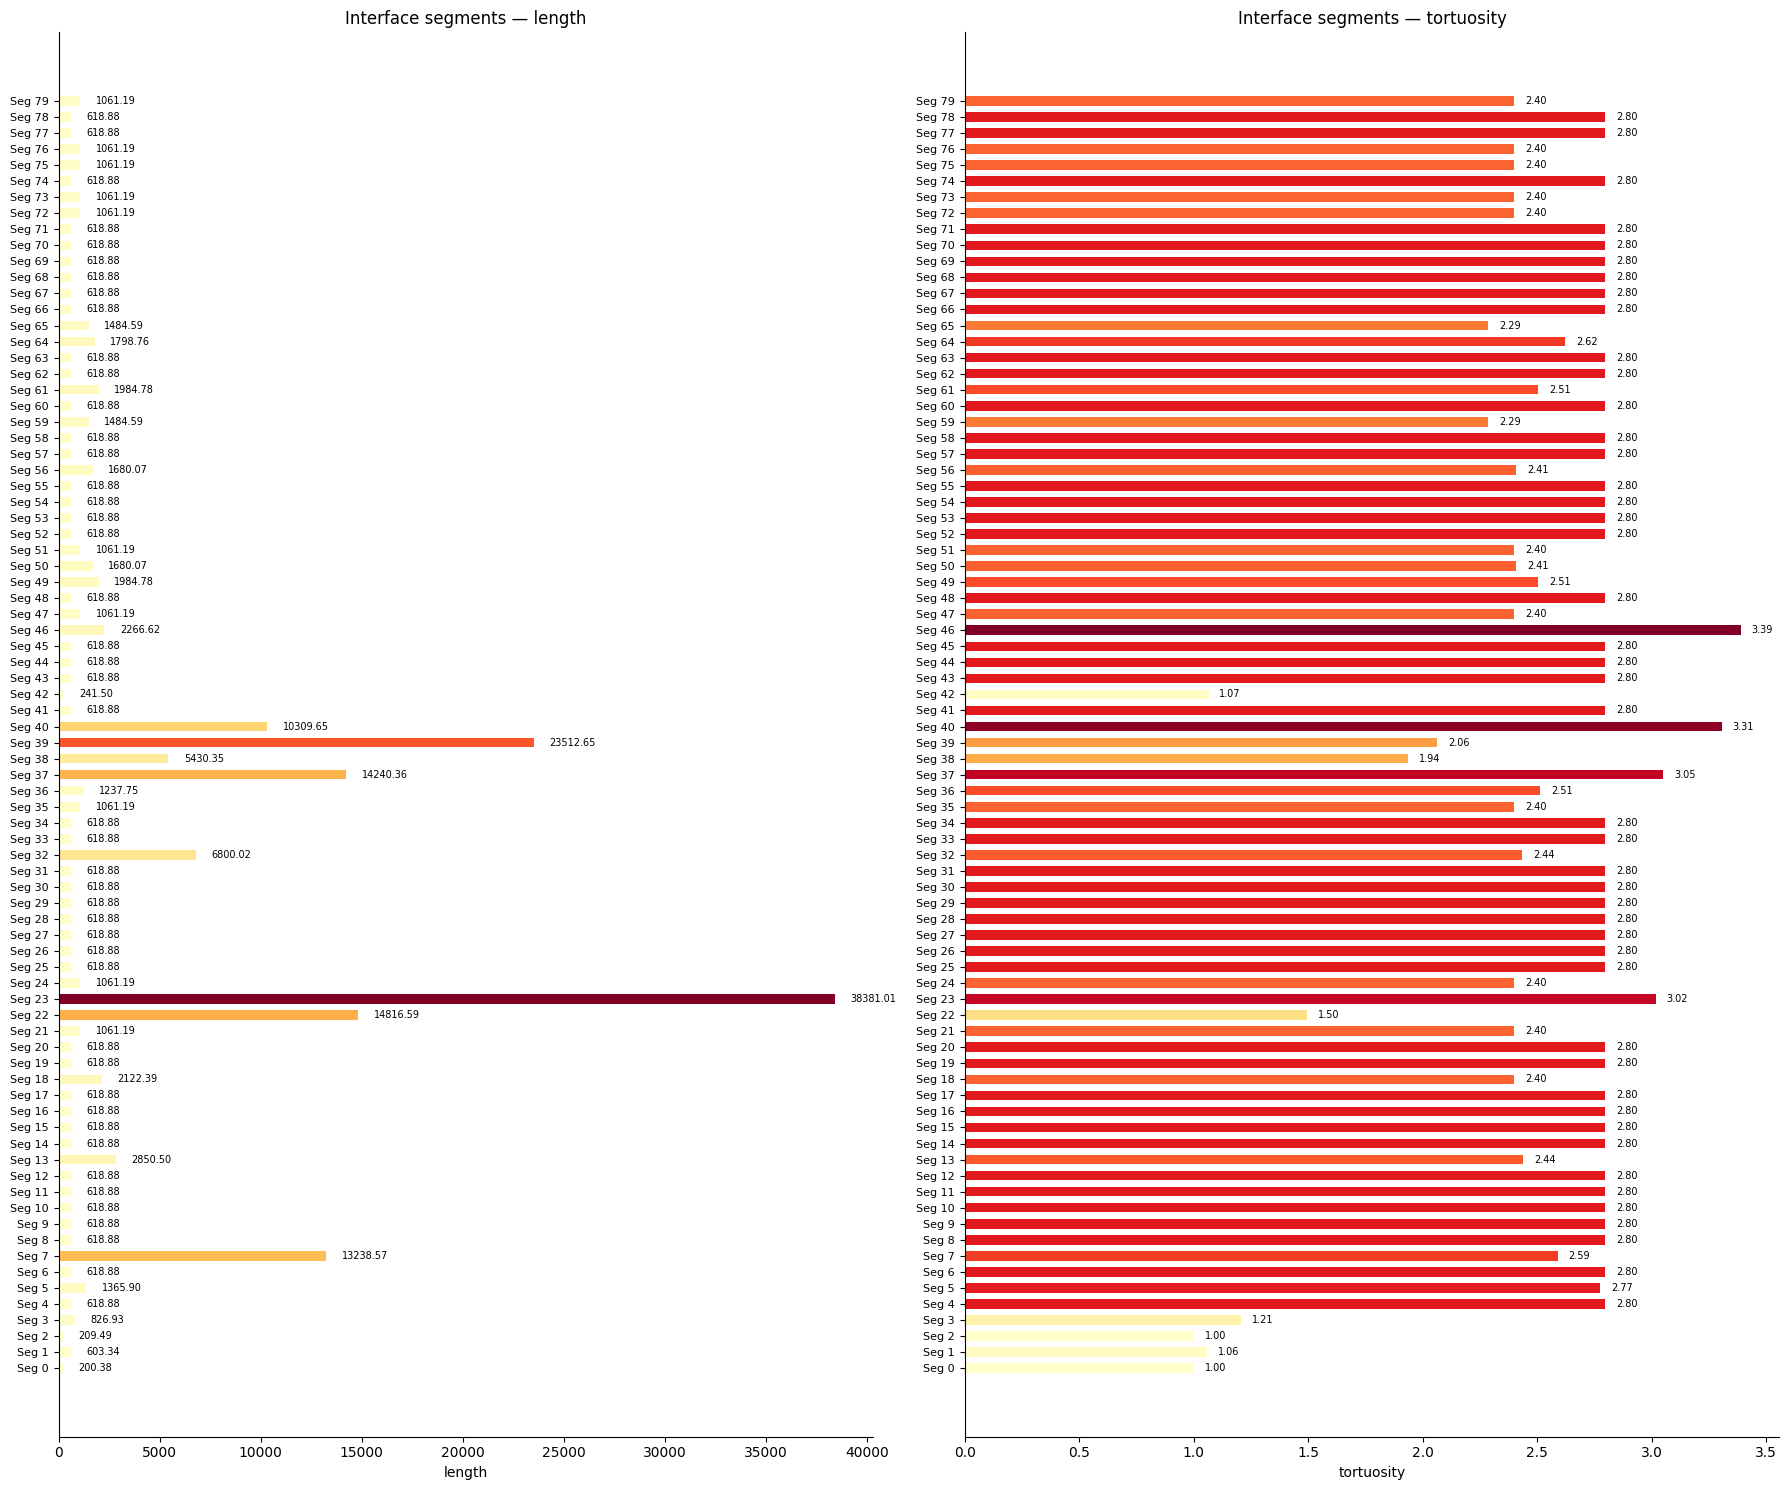

In [6]:
# Segment metrics table
print(result.segments[['segment_id', 'length', 'tortuosity', 'n_cells_a', 'n_cells_b']])

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 15))
for ax, metric in zip(axes, ['length', 'tortuosity']):
    sj.visualization.plot_interface_point_metrics(
        result, metric=metric, ax=ax, show=True,
    )
plt.tight_layout()
plt.show()

In [7]:
# 2. Filter out short segments
filtered_result = spoint.filter_interface(
  sp, result,
  min_segment_length=3000,     # drop segments shorter than 3000 coord units
  group_col='cell_type',
  store=True,                  # updates 'interface_label' in cell_meta
)

  Filtered: kept 8 segments, dropped 72 (min_length=3000)
  Updated 'interface_label' in cell_meta


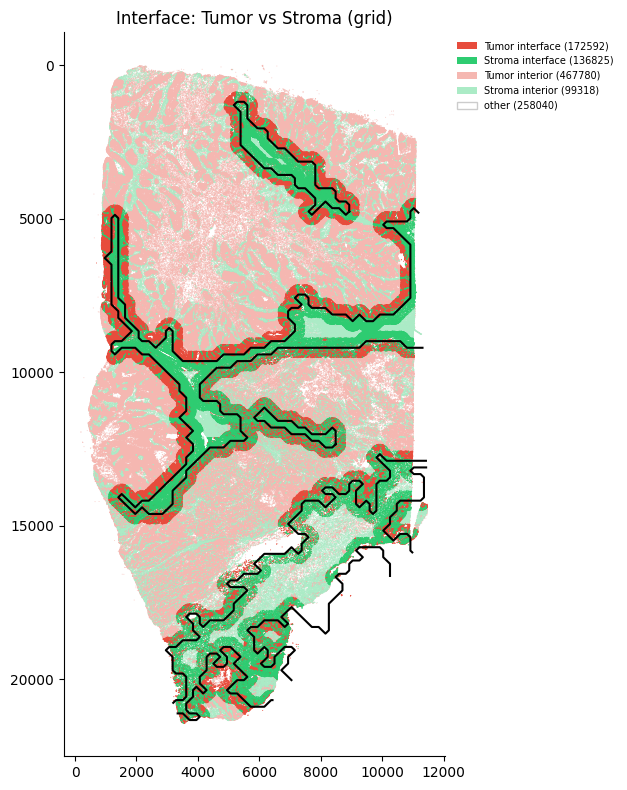

In [8]:
# Visualize — cells colored by interface role, contour lines overlay
sj.visualization.plot_interface_point_map(
    sp, filtered_result,
    color_a='#e74c3c',     # red for region A
    color_b='#2ecc71',     # green for region B
    point_size=0.5,
    contour_width=1.5,
    dpi=200, show_seg_labels=False
)

---
## 2. Region Classification

`classify_regions` assigns **every** cell (including immune, unclassified, etc.) to region A or B based on which side of the interface it falls on. Uses a high-resolution grid with majority voting.

The `min_segment_length` parameter filters out small noisy zones — zones with a perimeter shorter than this value are absorbed into the surrounding region.

In [9]:
# Classify all cells as region_a or region_b
sides = spoint.classify_regions(
    sp, filtered_result,
    group_col='cell_type',
    min_segment_length=3000,   # filter small noisy zones (perimeter in coord units)
    coord_type='global',
    store=True,               # saves 'region_side' to cell_meta
)

print(sides.value_counts())

  Region classification: 878,875 region_a, 255,680 region_b
  Stored in cell_meta['region_side']
region_side
region_a    878875
region_b    255680
Name: count, dtype: int64


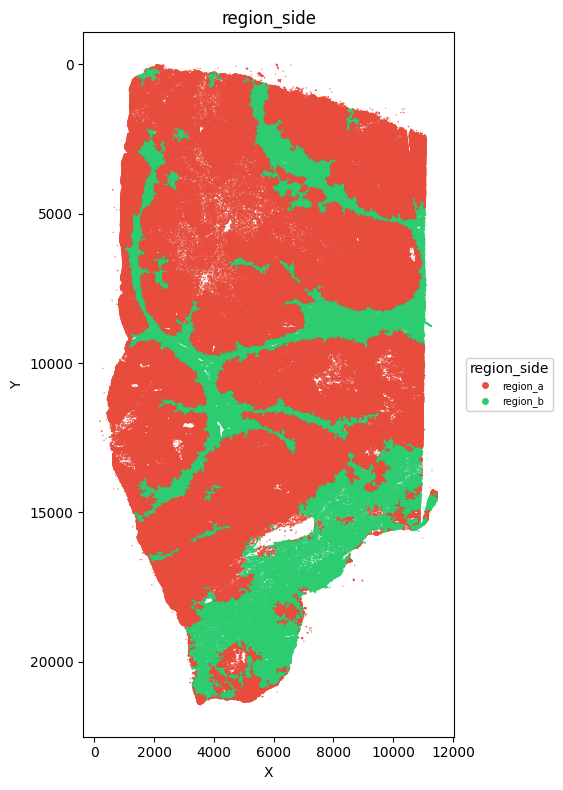

In [10]:
sj.visualization.xenium_plot_spatial(sp, 'region_side',
  color_dict={'region_a': '#e74c3c', 'region_b': '#2ecc71'})

---
## 3. Gradient Analysis

How do genes and cell features change as you move across the interface?

Positive distance = region A side, negative distance = region B side.

### 3a. Gene expression gradients

/tmp/ipykernel_131956/522246891.py:2: UserWarning: Skipping 3 genes not found in expression: ['VIM', 'COL1A1', 'MMP2']
  gradient = spoint.compute_gradient(


Gene gradients (sorted by |coefficient|):
           coef        pvalue        r2                trend
gene                                                        
EPCAM  0.000618  0.000000e+00  0.102040  increasing_toward_a
TGFB1 -0.000028  0.000000e+00  0.003669  increasing_toward_b
CD274  0.000009  1.055664e-47  0.000186  increasing_toward_a


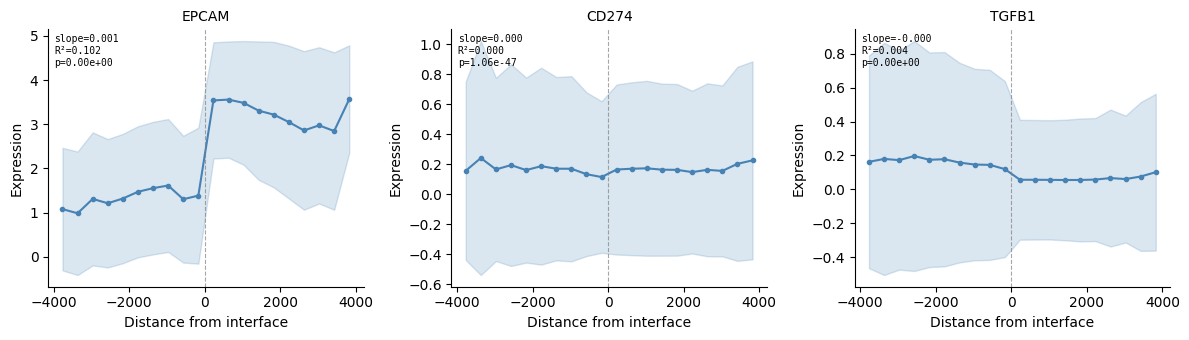

In [11]:
# Compute gradient for selected genes
gradient = spoint.compute_gradient(
    sp,
    interface_result=filtered_result,
    genes=['EPCAM', 'VIM', 'COL1A1', 'MMP2', 'CD274', 'TGFB1'],  # adjust to your panel
    layer='log_normalized',      # use normalized expression
    n_bins=20,
    coord_type='global',
)

# Which genes change most across the boundary?
print("Gene gradients (sorted by |coefficient|):")
print(gradient.gene_gradients.sort_values('coef', key=abs, ascending=False))

# Plot gradient curves
sj.visualization.plot_gradient_curve(gradient)

  Filtering to 640372 cells of types ['Tumor']


/tmp/ipykernel_131956/1233071785.py:2: UserWarning: Skipping 3 genes not found in expression: ['VIM', 'COL1A1', 'MMP2']
  gradient = spoint.compute_gradient(


Gene gradients (sorted by |coefficient|):
               coef    pvalue        r2                trend
gene                                                        
EPCAM -2.547314e-04  0.000000  0.017643  increasing_toward_b
CD274 -1.776551e-06  0.036322  0.000007  increasing_toward_b
TGFB1  4.321461e-07  0.280061  0.000002                 flat


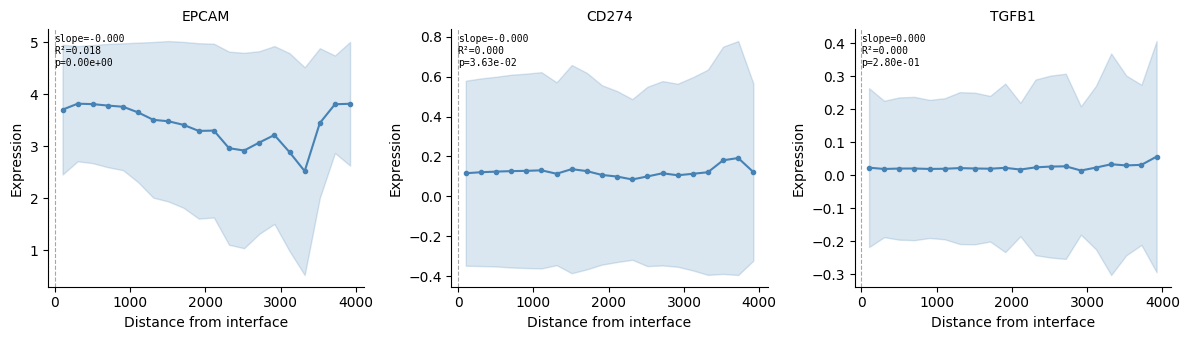

In [15]:
# Compute gradient for selected genes
gradient = spoint.compute_gradient(
    sp,
    interface_result=filtered_result,
    genes=['EPCAM', 'VIM', 'COL1A1', 'MMP2', 'CD274', 'TGFB1'],  # adjust to your panel
    layer='log_normalized',      # use normalized expression
    n_bins=20,
    coord_type='global',
    cell_type_col= 'cell_type',
    cell_types=['Tumor']
)

# Which genes change most across the boundary?
print("Gene gradients (sorted by |coefficient|):")
print(gradient.gene_gradients.sort_values('coef', key=abs, ascending=False))

# Plot gradient curves
sj.visualization.plot_gradient_curve(gradient)

  Filtering to 258040 cells of types ['B', 'T', 'Myeloid']


/tmp/ipykernel_131956/1257084050.py:2: UserWarning: Skipping 3 genes not found in expression: ['VIM', 'COL1A1', 'MMP2']
  gradient = spoint.compute_gradient(


Gene gradients (sorted by |coefficient|):
           coef        pvalue        r2                trend
gene                                                        
EPCAM  0.000423  0.000000e+00  0.059634  increasing_toward_a
CD274  0.000024  6.657040e-46  0.000784  increasing_toward_a
TGFB1 -0.000011  3.346248e-15  0.000240  increasing_toward_b


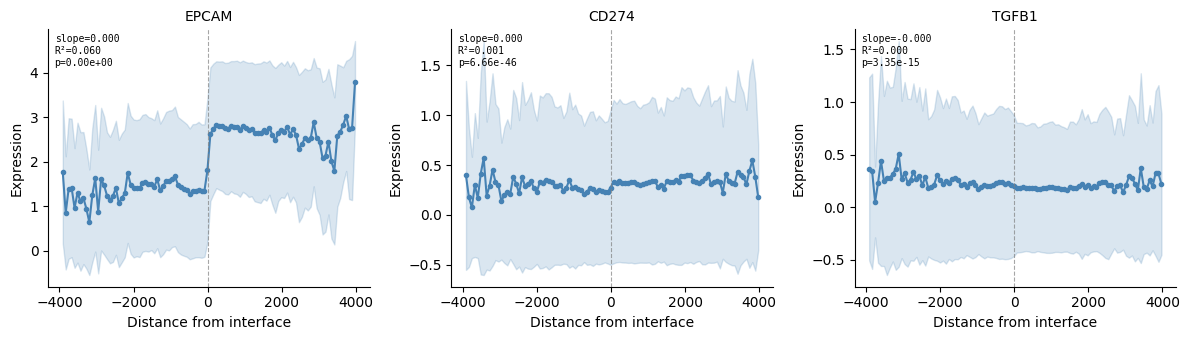

In [17]:
# Compute gradient for selected genes
gradient = spoint.compute_gradient(
    sp,
    interface_result=filtered_result,
    genes=['EPCAM', 'VIM', 'COL1A1', 'MMP2', 'CD274', 'TGFB1'],  # adjust to your panel
    layer='log_normalized',      # use normalized expression
    n_bins=100,
    coord_type='global',
    cell_type_col= 'cell_type',
    cell_types=['B', 'T', 'Myeloid']
)

# Which genes change most across the boundary?
print("Gene gradients (sorted by |coefficient|):")
print(gradient.gene_gradients.sort_values('coef', key=abs, ascending=False))

# Plot gradient curves
sj.visualization.plot_gradient_curve(gradient)

### 3b. Cell meta feature gradients

Analyze how morphology metrics, pathway activity scores, or any numeric `cell_meta` column changes across the interface.

In [ ]:
# Gradient of cell_meta features
# Adjust feature names to what's available in your cell_meta
gradient_features = spoint.compute_gradient(
    sp,
    interface_result=result,
    genes=None,                  # skip genes
    features=[
        'morph_area',            # cell size
        'morph_circularity',     # cell shape roundness
        'morph_elongation',      # cell elongation
    ],
    n_bins=20,
    coord_type='global',
)

print("Feature gradients:")
print(gradient_features.gene_gradients)

sj.visualization.plot_gradient_curve(gradient_features)

### 3c. Cell filtering

Focus the gradient on specific subsets of cells.

In [ ]:
# Only region A + B cells (exclude immune / unclassified "other" cells)
gradient_regions = spoint.compute_gradient(
    sp, result, genes=['EPCAM', 'VIM'],
    cells='regions_only',
    layer='log_normalized',
)

# Only specific cell types
gradient_types = spoint.compute_gradient(
    sp, result, genes=['EPCAM', 'VIM'],
    cell_types=['Tumor', 'Stroma', 'Macrophage'],
    cell_type_col='cell_type',
    layer='log_normalized',
)

### 3d. Spatial distance field

Visualize the signed distance from the interface to verify the boundary makes biological sense.

In [ ]:
# Visualize signed distance from the interface
sj.visualization.plot_spatial_distance(
    sp, gradient.distances,
    interface_result=result,     # overlay contour lines
    show=True,
)

---
## 4. Infiltration Scoring

Are immune cells (CD8 T cells, macrophages, etc.) penetrating into the target region, or are they excluded at the boundary?

The function:
1. Computes signed distance of every cell to the interface
2. Auto-detects the target region (the side with *fewer* immune cells — they're the visitors)
3. Classifies each immune cell as "infiltrating" or "resident"
4. Fits a density gradient (slope + p-value) per immune type

             median_depth    max_depth  density_slope  density_pvalue  \
immune_type                                                             
T              695.569322  4011.767708       0.823838        0.649218   
Myeloid        627.339215  4013.469843       1.041699        0.715502   
B              893.240267  3925.770763       0.077705        0.894604   

             infiltration_fraction  n_infiltrating  n_resident  
immune_type                                                     
T                         0.748235           67621       22753  
Myeloid                   0.723286           96819       37041  
B                         0.496835           16796       17010  


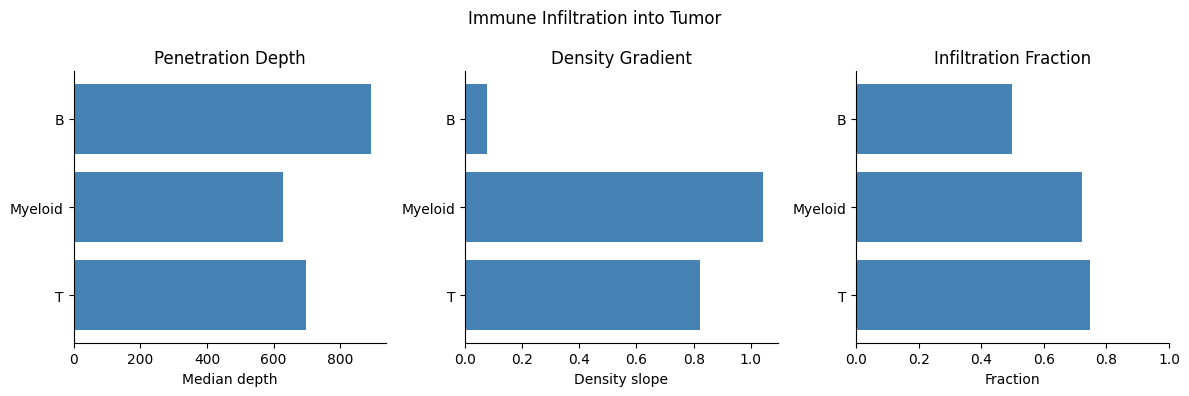

In [18]:
# Score immune infiltration
# Adjust immune_types to match your cell type labels
infiltration = spoint.score_infiltration(
    sp,
    interface_result=filtered_result,
    immune_col='cell_type',                              # column with cell labels
    immune_types=['T', 'Myeloid', 'B'],      # immune cell labels
    target_region='Tumor',                               # or None for auto-detect
    depth_bins=10,
    coord_type='global',
)

# Per-type metrics
print(infiltration.per_type_metrics)

# Visualize
sj.visualization.plot_infiltration_summary(infiltration)

             median_depth    max_depth  density_slope  density_pvalue  \
immune_type                                                             
T              323.851229  3947.875624       0.823838        0.649218   
Myeloid        299.988825  3949.280217       1.041699        0.715502   
B              528.960755  3931.472550       0.077705        0.894604   

             infiltration_fraction  n_infiltrating  n_resident  
immune_type                                                     
T                         0.251765           22753       67621  
Myeloid                   0.276714           37041       96819  
B                         0.503165           17010       16796  


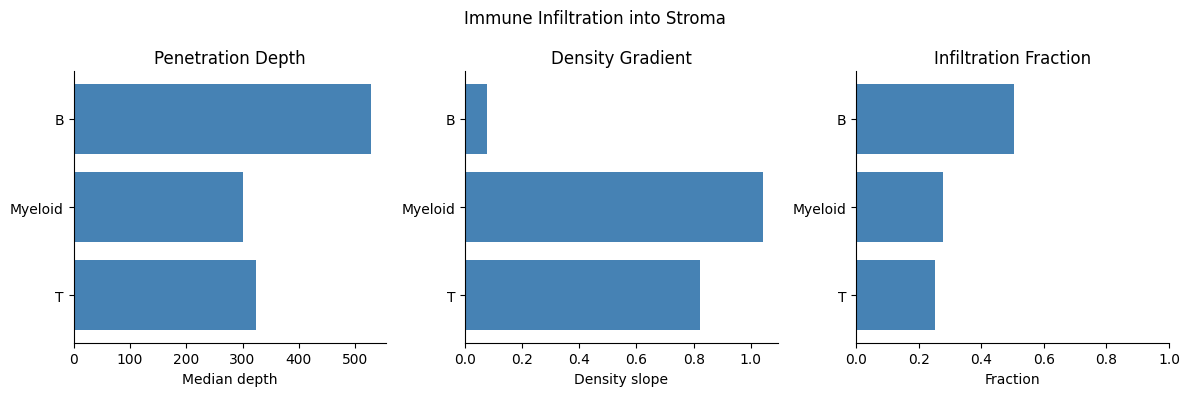

In [19]:
# Score immune infiltration
# Adjust immune_types to match your cell type labels
infiltration = spoint.score_infiltration(
    sp,
    interface_result=filtered_result,
    immune_col='cell_type',                              # column with cell labels
    immune_types=['T', 'Myeloid', 'B'],      # immune cell labels
    target_region='Stroma',                               # or None for auto-detect
    depth_bins=10,
    coord_type='global',
)

# Per-type metrics
print(infiltration.per_type_metrics)

# Visualize
sj.visualization.plot_infiltration_summary(infiltration)

---
## 5. Auto-discover Gene Programs

Find gene modules that co-vary across the interface using NMF or PCA.

In [ ]:
# Auto-discover gene programs via NMF
gradient_programs = spoint.compute_gradient(
    sp, filtered_result,
    genes=None,                  # use all genes
    layer='log_normalized',
    auto_programs='nmf',         # or 'pca'
    n_auto_programs=5,
    n_bins=20,
)

# Which programs have the strongest spatial gradient?
print("Program gradients:")
print(gradient_programs.program_gradients.sort_values('coef', key=abs, ascending=False))

# Plot the top program
top_program = gradient_programs.program_gradients['coef'].abs().idxmax()
sj.visualization.plot_gradient_curve(gradient_programs, programs=[top_program])

---
## Quick Reference

```python
import spatioloji_s.spatial.point as spoint  # same as sj.spatial.polygon

# -- Interface detection (grid-based, no graph needed) ------
result = spoint.identify_interface(sp,
    group_col='cell_type', region_a='Tumor', region_b='Stroma',
    grid_resolution=50, min_interface_cells=10)

# -- Region classification ----------------------------------
sides = spoint.classify_regions(sp, result,
    group_col='cell_type', min_segment_length=500)

# -- Gradient analysis --------------------------------------
# Gene expression
gradient = spoint.compute_gradient(sp, result,
    genes=['EPCAM', 'VIM'], layer='log_normalized')

# Cell meta features
gradient = spoint.compute_gradient(sp, result,
    features=['morph_area', 'morph_circularity'])

# Both together
gradient = spoint.compute_gradient(sp, result,
    genes=['EPCAM'], features=['morph_area'], layer='log_normalized')

# Auto-discover programs
gradient = spoint.compute_gradient(sp, result,
    auto_programs='nmf', n_auto_programs=5, layer='log_normalized')

# -- Infiltration scoring -----------------------------------
infiltration = spoint.score_infiltration(sp, result,
    immune_col='cell_type', immune_types=['CD8_T', 'Macrophage'])

# -- Visualization ------------------------------------------
sj.visualization.plot_interface_point_map(sp, result)
sj.visualization.plot_interface_point_metrics(result, metric='tortuosity')
sj.visualization.plot_gradient_curve(gradient)
sj.visualization.plot_spatial_distance(sp, gradient.distances, interface_result=result)
sj.visualization.plot_infiltration_summary(infiltration)
```

## Interpretation Guide

| Metric | Value | Meaning |
|--------|-------|---------|
| **Tortuosity** | ~1.0 | Smooth pushing border (better prognosis) |
| | >1.5 | Irregular invasive front (worse prognosis) |
| **Infiltration fraction** | High | Immune cells penetrating target region |
| | Low | Immune cells excluded from target region |
| **Gradient coef** | Positive | Expression increases toward region A |
| | Negative | Expression increases toward region B |
| | ~0 | No spatial gradient |
| **Density slope** | Negative toward target | Immune density drops with depth (excluded) |
| | Flat | Even distribution (fully infiltrated) |